# Flashzoi/Borzoi

In [2]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd
import polars as pl
import numpy as np
import torch
import genvarloader as gvl
import pooch
from tempfile import TemporaryDirectory
from pathlib import Path
from tqdm import tqdm

import src.utils as utils
from torch.amp import autocast
import src.GVL as GVL
import src.flashzoi as fz
import src.clinvar as cv
import src.vep_analysis as va
import src.text2term as tt
import src.vep_pipeline as vp

pd.set_option('display.max_columns', None)

utils.set_rcparams_nature()

# Set seed
np.random.seed(42)
torch.manual_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Check the max batch size for the model before running out of GPU memory.

In [5]:
%%capture

trks_dict = fz.test_batch_sizes(batch_sizes=range(5,100), 
                             L=2**19,
                             model=model,  
                             device=device)

## Run flashzoi

In [6]:
seq_wt = utils.random_seqs(N=2, L=2**18, as_str=True)
seq_mut = [utils.get_mutated_sequence(seq) for seq in seq_wt]

trks_wt = fz.score_all_tracks(seq_wt, model=model, device=device, run_squeeze=True)
trks_mut = fz.score_all_tracks(seq_mut, model=model, device=device, run_squeeze=True)
delta = trks_mut - trks_wt

delta_metrics = fz.compute_vep_metrics(trks_wt=trks_wt, 
                                        trks_mut=trks_mut)
delta_metrics

Mutating 1.0% of sequence
Mutating 1.0% of sequence


{'trks_wt': tensor([[[0.0159, 0.0243, 0.0099,  ..., 0.0062, 0.0087, 0.0151],
          [0.0270, 0.0329, 0.0212,  ..., 0.0210, 0.0246, 0.0321],
          [0.0082, 0.0099, 0.0045,  ..., 0.0025, 0.0038, 0.0053],
          ...,
          [0.0039, 0.0052, 0.0043,  ..., 0.0062, 0.0061, 0.0072],
          [0.0052, 0.0073, 0.0060,  ..., 0.0086, 0.0086, 0.0105],
          [0.0051, 0.0074, 0.0064,  ..., 0.0090, 0.0090, 0.0103]],
 
         [[0.0021, 0.0043, 0.0021,  ..., 0.0060, 0.0050, 0.0087],
          [0.0064, 0.0039, 0.0055,  ..., 0.0150, 0.0111, 0.0173],
          [0.0012, 0.0028, 0.0013,  ..., 0.0019, 0.0012, 0.0020],
          ...,
          [0.0009, 0.0008, 0.0011,  ..., 0.0025, 0.0030, 0.0038],
          [0.0012, 0.0011, 0.0015,  ..., 0.0036, 0.0043, 0.0054],
          [0.0014, 0.0012, 0.0018,  ..., 0.0042, 0.0049, 0.0056]]]),
 'trks_mut': tensor([[[0.0163, 0.0238, 0.0096,  ..., 0.0052, 0.0069, 0.0086],
          [0.0273, 0.0324, 0.0205,  ..., 0.0218, 0.0274, 0.0611],
          [0.0085

## Run PCA on tracks delta

Here we input the delta array after taking the absolute values (since we don't care about directionality, just the amount of change in predictions).

In [39]:
import src.dimreduction as dr

pca_result =  dr.pca_sklearn(delta.abs().cpu())
{k:v.shape for k,v in pca_result.items() if k!="model"}

{'eigenvalues': (100,),
 'eigenvectors': (100, 6144),
 'projections': (7611, 100),
 'explained_variance_ratio': (100,)}

Import metadata for Flashzoi tracks.

In [26]:
# Check that they have the same number of rows
# (assuming that the rows are the same order)
targets = fz.load_targets(species=["human"])
print(targets["source"].value_counts())

source
encode      5855
fantom      1276
catlas       222
geo          169
recount3      89
Name: count, dtype: int64


Merge metadata with PCA projections.

In [27]:
X = pca_result["projections"]
# Convert PCA projections to DataFrame
pca_df = pd.DataFrame(
    X,
    columns=[f"PC{i+1}" for i in range(X.shape[1])]
)
assert targets.shape[0] == X.shape[0]
pca_df = pd.concat([targets.reset_index(), pca_df], axis=1)

### Get the samples that are driving the delta

We want to now which tissues/cell types are most affected by the mutation(s). We can run a PC on the delta of the two sets of tracks to find this out.

In [28]:
def get_top_loadings(pca_df,
                     groupby_col,
                     top_n = 5, 
                     exp=2,
                     max_pcs = 2):
    if groupby_col not in pca_df.columns:
        raise ValueError(f"Column '{groupby_col}' not found in DataFrame. Available columns: {pca_df.columns.tolist()}")
    top_res = {}
    for i in range(max_pcs):
        pc = f"PC{i+1}"
        top_res[pc] = pca_df.groupby(groupby_col)[pc].apply(lambda x:  (x**exp).mean()).sort_values(ascending=False).head(top_n)
        print(f"\n{pc} ({(pca_result["explained_variance_ratio"][i]*100).round(2)}% variance explained)")
        print(top_res[pc])

#### By assays

In [29]:
top_assays = get_top_loadings(pca_df, groupby_col="assay")


PC1 (84.58% variance explained)
assay
CHIP     4807.558205
CAGE      834.162828
RNA       795.586539
DNASE     683.157377
ATAC      516.130770
Name: PC1, dtype: float64

PC2 (3.69% variance explained)
assay
CHIP     226.428565
CAGE      18.625987
RNA       17.286147
DNASE     11.418100
ATAC      10.470451
Name: PC2, dtype: float64


#### By tissues

In [30]:
top_tissues = get_top_loadings(pca_df, groupby_col="tissue")


PC1 (84.58% variance explained)
tissue
H3K9me3:CD4-positive, alpha-beta T cell male adult (37 years)    851394.526574
H3K9me3:B cell male adult (37 years)                             655707.453302
H3K9me3:AG04450                                                  561885.636539
H3K9me3:CD14-positive monocyte male adult (21 year)              442165.927299
H3K9me3:stomach female embryo (96 days)                          277045.048671
Name: PC1, dtype: float64

PC2 (3.69% variance explained)
tissue
H3K9me3:CD4-positive, alpha-beta T cell male adult (37 years)                                                   22537.019603
H3K9me3:AG04450                                                                                                 17130.725972
H3K9me3:B cell male adult (37 years)                                                                            16107.174228
EZH2:GM23338 male adult (53 years) originated from GM23248                                                      14261.879262


### Get track sample metadata

{work in progress}

In [31]:
# import glob
# pd.set_option('display.max_columns', None)

# # Find all JSON files in the BioSamples directory
# json_files = glob.glob(os.path.expanduser("~/projects/data/BioSamples/*.json"))

# # Read and merge all JSON files into a single DataFrame
# biosamples_dfs = []
# for f in json_files:
#     query = os.path.basename(f).split(".")[0]
#     print(os.path.basename(f))
#     bs = pd.read_json(f) 
#     # Expand the nested characteristics dictionary into separate columns
#     bs = pd.concat([
#         bs.drop('characteristics', axis=1),
#         pd.json_normalize(bs['characteristics'].apply(lambda x: {k: v[0]['text'] if isinstance(v, list) and len(v) > 0 else None for k, v in x.items()}))
#     ], axis=1) 

#     print(bs.shape)
#     # bs = bs.loc[bs["name"].str.startswith("ENCODE")]
#     bs.insert(0,"query", query)
#     bs.insert(0,"id", bs["name"].str.split(" ").str[-1])

#     cols = ["sample type","cell type","tissue", "cell line"]
#     cols = [c for c in cols if c in bs.columns]
#     bs.loc[:,'sample'] = pd.NA
#     bs.loc[:,'sample'] = bs['sample'].fillna(bs[cols[1:]].bfill(axis=1).iloc[:, 0])
    
#     print({c:bs[c].notna().sum() for c in cols+["sample"]})
    
#     bs.fillna({"sample": "other"}, inplace=True)
#     extra_cols = ["id","ENCODE accession","name","sample"]
#     extra_cols = [c for c in extra_cols if c in bs.columns]
#     bs = bs.loc[:,extra_cols+cols]

#     biosamples_dfs.append(bs)

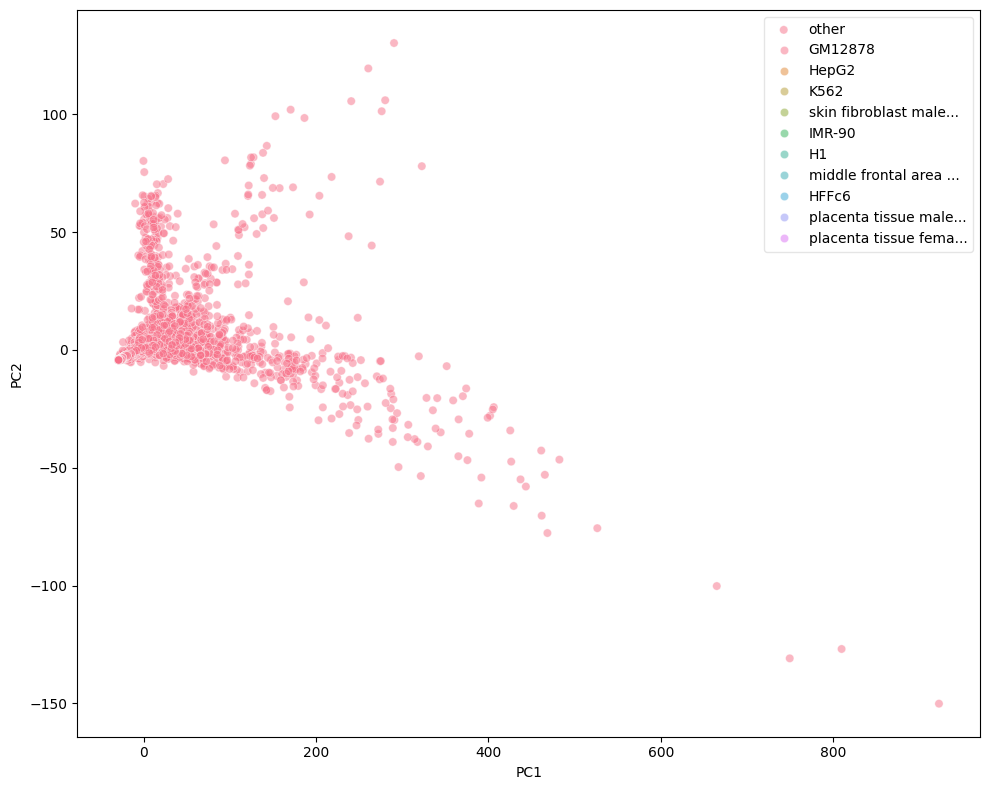

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


trunc = 20
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="top_tissue", alpha=0.5)
legend = plt.legend(loc='upper right', 
                   labels=[label[:trunc] + '...' if len(label) > trunc else label 
                          for label in plt.gca().get_legend_handles_labels()[1]])
# Make legend background semi-transparent
legend.get_frame().set_alpha(0.5)
plt.tight_layout()

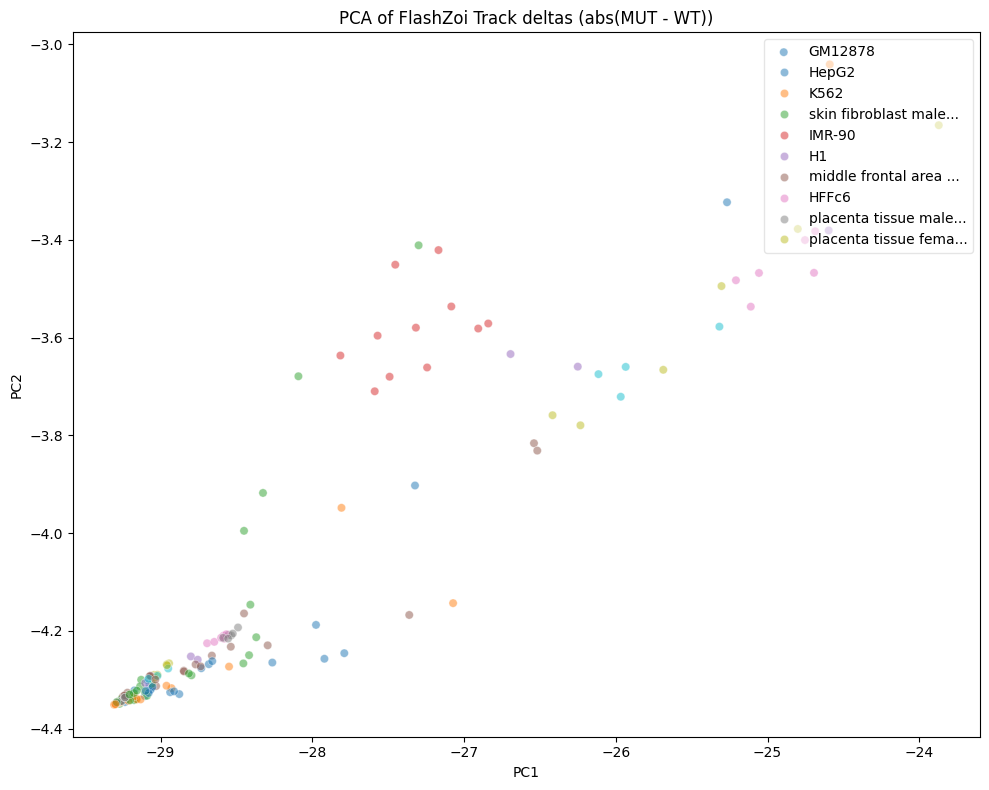

In [33]:
plt.figure(figsize=(10, 8))
# Plot "other" points first with small size and low alpha
# sns.scatterplot(data=pca_df.loc[pca_df["top_tissue"]=="other"], x="PC1", y="PC2", hue="top_tissue", alpha=0.1, size=0.1, legend=False)
# Plot labeled points on top with normal size
sns.scatterplot(data=pca_df.loc[pca_df["top_tissue"]!="other"], x="PC1", y="PC2", hue="top_tissue", alpha=0.5)
plt.title('PCA of FlashZoi Track deltas (abs(MUT - WT))')
legend = plt.legend(loc='upper right', 
                   labels=[label[:trunc] + '...' if len(label) > trunc else label 
                          for label in plt.gca().get_legend_handles_labels()[1]])
# Make legend background semi-transparent
legend.get_frame().set_alpha(0.5)
plt.tight_layout()

## Compute cosine similarity

### Directly on logits

Compute cosin similarity along the tracks or sequence axes.

In [34]:
import src.vep_metrics as vm

css = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(out1,
                        out2,
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7611, 6144])
CSS mean: tensor(1., device='cuda:2')
CSS variance: tensor(0., device='cuda:2')

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([1, 6144])
CSS mean: tensor(0.9579, device='cuda:2')
CSS variance: tensor(0.0016, device='cuda:2')


### On PCA eigenvectors


Reduce the track predictions from both sequences in one PCA. Then extract the eigenvectors (100 PCs x sequence length) for each sequence and compare them with cosine similarity.

Note: Here we don't want to take the absolute of the track values, because we need to retain info about directionality for comparing the two PCA embeddings afterwards.

In [40]:
pca_ax0 =  dr.pca_sklearn(torch.concat([out1,out2], axis=1).cpu())

In [41]:
css_pca_ax0 = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca_ax0["eigenvectors"][:,1:out1.shape[1]],
                        pca_ax0["eigenvectors"][:,out1.shape[1]+1:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca_ax0[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([6143])
CSS mean: tensor(0.0028, dtype=torch.float64)
CSS variance: tensor(0.0105, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(-0.0008, dtype=torch.float64)
CSS variance: tensor(0.0095, dtype=torch.float64)


Compute cosin similarity along the sequence axis instead.

In [42]:
pca_ax1 = dr.pca_sklearn(torch.concat([out1,out2], axis=0).cpu())

In [43]:
css_pca_ax1 = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca_ax1["projections"][1:out1.shape[0],:],
                        pca_ax1["projections"][out1.shape[0]+1:,:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca_ax1[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(-0.0052, dtype=torch.float64)
CSS variance: tensor(0.0975, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7610])
CSS mean: tensor(0.5351, dtype=torch.float64)
CSS variance: tensor(0.3527, dtype=torch.float64)


### Compare direct vs. PCA cos sim

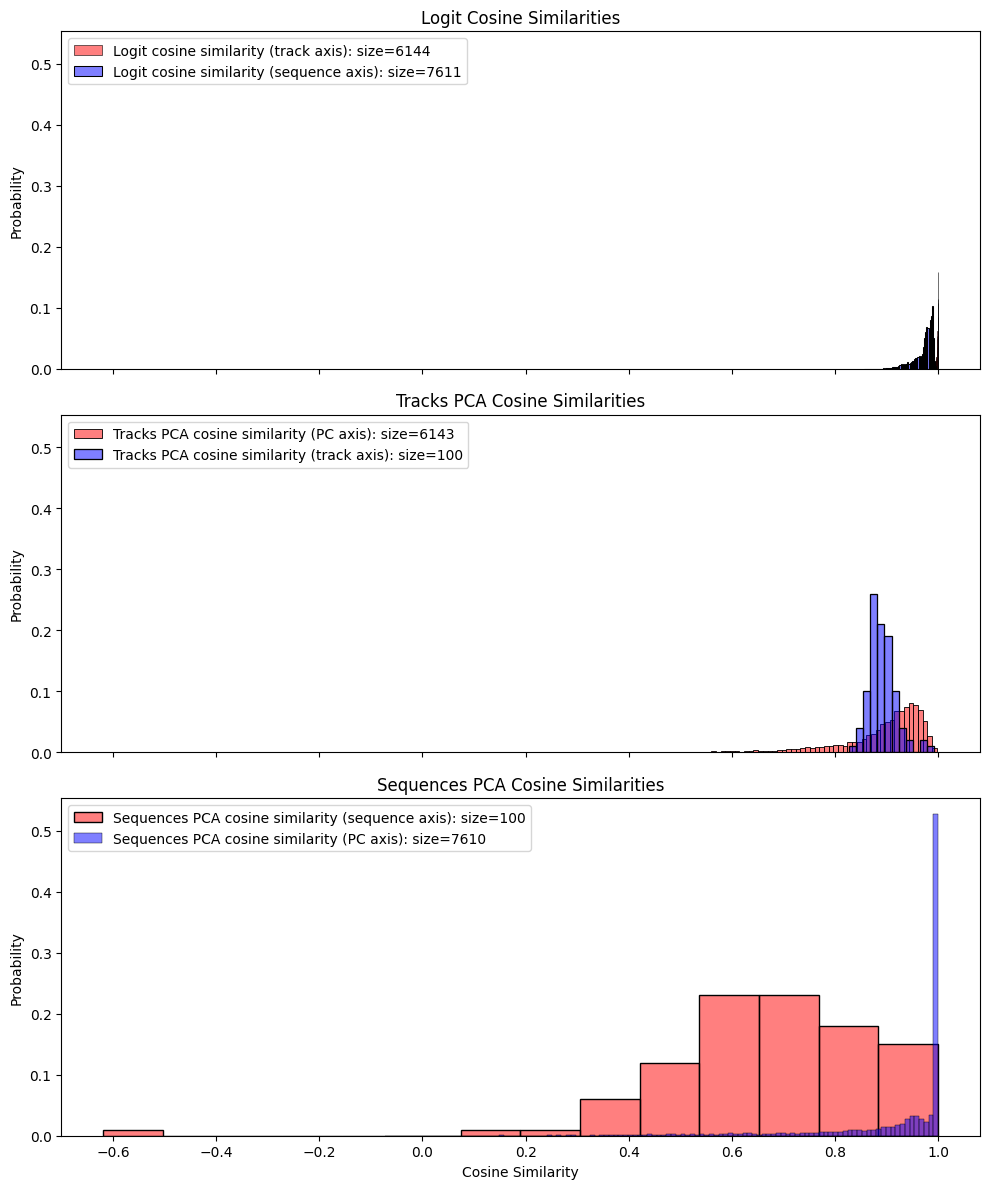

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), 
                               sharex=True, 
                               sharey=True)
colors=["red","blue"]
stat="probability"
bins="auto"

# Top subplot - Logit cosine similarities
colors=["red","blue"]
axis_names = ["track","sequence",]
for i, (dim, data) in enumerate(css.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Logit cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax1)
ax1.set_xlabel('Cosine Similarity')
ax1.set_title('Logit Cosine Similarities')
ax1.legend(loc='upper left')


# Middle subplot - track PCA cosine similarities
axis_names = ["PC","track"]
for i, (dim, data) in enumerate(css_pca_ax0.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Tracks PCA cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax2)
ax2.set_xlabel('Cosine Similarity')
ax2.set_title('Tracks PCA Cosine Similarities')
ax2.legend(loc='upper left')



# Botom subplot - sequence PCA cosine similarities
axis_names = ["sequence","PC"]
for i, (dim, data) in enumerate(css_pca_ax1.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Sequences PCA cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax3)
ax3.set_xlabel('Cosine Similarity')
ax3.set_title('Sequences PCA Cosine Similarities')
ax3.legend(loc='upper left')

# sns.histplot(data=css_pca.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (track axis)', color='red', ax=ax2)
# sns.histplot(data=css_pca_ax1.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (sequence axis)', color='blue', ax=ax2)
# ax2.set_xlabel('Cosine Similarity')
# ax2.set_title('PCA Cosine Similarities')
# ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Run flashzoi in batches of sequences

In [2]:
# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
)


In [3]:
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz") 
# bed = gvl.read_bedlike(bed_path)

print(bed.shape)
bed.head()

(13771, 25)


chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i64,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",2,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""


In [4]:
ds_path = TemporaryDirectory(suffix=".gvl").name

bed_chrom = bed.filter(pl.col('chrom').str.replace("chr","")=='22')
force = False
if not os.path.exists(ds_path) or force:
    gvl.write(
        path=ds_path,
        bed=gvl.with_length(bed_chrom[:20], 2**18),  # change region length to 131,072 bp
        variants=variants,
        overwrite=True,
    )

2025-05-23 18:20:25.525 | INFO     | genvarloader._dataset._write:write:75 - Writing dataset to /tmp/tmpbj57mi4b.gvl
2025-05-23 18:20:25.531 | INFO     | genoray._pgen:_read_index:1078 - Loading genoray index.


2025-05-23 18:20:25.922 | INFO     | genvarloader._dataset._write:write:147 - Using 451 samples.
2025-05-23 18:20:25.922 | INFO     | genvarloader._dataset._write:write:153 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

2025-05-23 18:20:27.255 | INFO     | genvarloader._dataset._write:write:177 - Finished writing.


In [71]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes") 
    .with_len(2**18)
)

ds_ref = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("reference") 
    .with_len(2**18)
)

2025-05-23 19:41:11.586 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 19:41:11.608 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 19:41:11.631 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /tmp/tmpbj57mi4b.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None

2025-05-23 19:41:11.634 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 19:41:11.655 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 19:41:11.673 | INFO  

In [72]:
# Convert BED to sites
sites = cv.bed_to_sites(bed) 

sites_chrom = sites.filter(pl.col("CHROM").str.replace("chr","")=="22")

# Import sites_ds
site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
site_ds_ref = gvl.DatasetWithSites(ds_ref, sites_chrom)

site_ds

In [91]:
row_idx = 0
wt_haps, mut_haps, flags = site_ds[row_idx, :]
print(wt_haps.haps.shape)
# Import the sequences for the REF sample
## All samples are REF, just use the first one
wt_haps_ref, mut_haps_ref, flags_ref = site_ds_ref[row_idx, [0]] 
wt_haps_ref.haps = wt_haps_ref.haps[0]
mut_haps_ref.haps = mut_haps_ref.haps[0]
print(wt_haps_ref.shape)


(451, 2, 262144)
(1, 2, 262144)


In [108]:
seq_as_str = False
sample_names = ds.samples[:10]

# Import all the haplotypes for region/batch
wt_haps, mut_haps, flags = site_ds[row_idx, sample_names] 

## Get the wildtype (wt) haplotype sequences
seq_wt = GVL.haps_to_seqs(haps=wt_haps,  
                            as_str=seq_as_str)
print(seq_wt.shape)

## Get the mutated (mut) haplotype sequences
seq_mut = GVL.haps_to_seqs(haps=mut_haps,  
                            as_str=seq_as_str) 

(20, 262144)


In [102]:
wt_haps_ref, mut_haps_ref, flags_ref = site_ds_ref[row_idx, [0]] 
print(wt_haps_ref.shape)

(1, 1, 2, 262144)


In [103]:
## Get the wildtype (wt) sequence and add to haplotype sequences
seq_wt_ref = GVL.haps_to_seqs(haps=wt_haps_ref,  
                                as_str=seq_as_str)
seq_wt = np.concatenate([seq_wt,seq_wt_ref], axis=0)    

In [107]:
seq_mut_ref = GVL.haps_to_seqs(haps=mut_haps_ref,  
                                                   as_str=seq_as_str)

seq_mut_ref

array([[b'T', b'G', b'A', ..., b'A', b'G', b'A'],
       [b'T', b'G', b'A', ..., b'A', b'A', b'C']],
      shape=(2, 262144), dtype='|S1')

In [109]:
from tqdm import tqdm
import torch
import src.flashzoi as fz

row_idx = 0

batches = utils.split_batches(ds.samples)

device = "cuda:1"
model = fz.load_model(device=device, eval=True)

batched_results = []

# Import all the haplotypes for the region at once to reduce overhead
wt_haps, mut_haps, flags = site_ds[row_idx, :]

# Iterate over batches
for batch_idx, sample_idx in tqdm(enumerate(batches),
                                  total=len(batches),
                                  desc="Iterating over batches",
                                  leave=False):     
    # Extract sequences
    seqs_wt =GVL.haps_to_seqs(haps=wt_haps,  
                              sample_idx=sample_idx,
                              as_str=False)
    seqs_mut = GVL.haps_to_seqs(haps=mut_haps, 
                                 sample_idx=sample_idx,
                                 as_str=False)
    
    # print("seqs.shape", seqs.shape)
    
    # Score tracks
    trks_wt = fz.score_all_tracks(seqs_wt, model=model, device=device)
    trks_mut = fz.score_all_tracks(seqs_mut, model=model, device=device)
    # print("trks.shape", trks.shape)

    break

    # Store results
    batched_results.append(trks_wt.cpu().numpy())
    
    # Free memory
    del seqs_wt, seqs_mut, trks_wt, trks_mut
    torch.cuda.empty_cache()
    
    



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [8]:
import src.flashzoi as fz

results = fz.compute_pca_metrics(trks_wt=trks_wt, 
                         trks_mut=trks_mut, 
                         verbose=True)

Computing PCA CSS:   0%|          | 0/24 [00:00<?, ?it/s]

Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating c

In [ ]:
results = fz.compute_delta_metrics(trks_wt=trks_wt, 
                         trks_mut=trks_mut, 
                         verbose=True)

results["delta_max_max"]

Computing delta metrics for batched results


tensor([0.0000, 0.0000, 2.1200, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        3.1762, 0.0000, 0.0000, 2.4953, 0.0000, 0.0000, 1.7168, 0.0000, 0.0000,
        2.2345, 0.0000, 0.0000, 2.5312, 0.0000, 0.0000])

## Disease-specific track analyses

**Objective**  

Determine whether interindividual variation in VEPs for variants associated with a specific disease (eg. Sickle cell anemia) are associated with variation in relevant tracks (eg. red blood cells).

Examples:
- Sickle Cell Anemia: 
    - "hereditary spherocytic anemia cell line"
    - "erythroblast"
    - "erythrocyte"
- Atrial fibrillation
    - "heart"



In [7]:
# Check that they have the same number of rows
# (assuming that the rows are the same order)
targets = fz.load_targets(species=["human"])

print(targets.shape)
print(targets["source"].value_counts()) 
targets.loc[targets['description'].str.lower().str.contains("anemia|erythrocyte|erythroblast")].description.unique()

(7611, 13)
source
encode      5855
fantom      1276
catlas       222
geo          169
recount3      89
Name: count, dtype: int64


array(['CAGE:hereditary spherocytic anemia cell line:WIL2-NS',
       'CAGE:CD34 cells differentiated to erythrocyte lineage, biol_',
       'ATAC:Fetal Erythroblast 1', 'ATAC:Fetal Erythroblast 2',
       'ATAC:Fetal Erythroblast 3', 'ATAC:Fetal Erythroblast 4',
       'ATAC:Fetal Erythroblast 5', 'CHIP:GATA1:erythroblast male',
       'CHIP:GATA1:erythroblast embryo (16-19 weeks)'], dtype=object)

In [8]:
targets = tt.get_top_ont_mappings(df=targets, 
                                  term_col="name",  
                                  top_n=1)
print(targets.shape)
targets.head()

Searching for 5479 terms

 EFO
2025-08-05 17:44:15 INFO [text2term.t2t]: Loading cached ontology from: /home/schilder/.cache/text2term/EFO/EFO-term-details.pickle
2025-08-05 17:44:16 INFO [text2term.t2t]: Filtered ontology terms to those of type: OntologyTermType.CLASS
2025-08-05 17:44:16 INFO [text2term.t2t]: Mapping 5479 source terms to EFO
2025-08-05 17:44:29 INFO [text2term.t2t]: ...done (mapping time: 13.16s seconds)

 UBERON
2025-08-05 17:44:29 INFO [text2term.t2t]: Loading cached ontology from: /home/schilder/.cache/text2term/UBERON/UBERON-term-details.pickle
2025-08-05 17:44:29 INFO [text2term.t2t]: Filtered ontology terms to those of type: OntologyTermType.CLASS
2025-08-05 17:44:29 INFO [text2term.t2t]: Mapping 5479 source terms to UBERON
2025-08-05 17:44:32 INFO [text2term.t2t]: ...done (mapping time: 2.82s seconds)

 CL
2025-08-05 17:44:32 INFO [text2term.t2t]: Loading cached ontology from: /home/schilder/.cache/text2term/CL/CL-term-details.pickle
2025-08-05 17:44:33 INFO [t

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/bioregistry/resource_manager.py:342: UserWarning: Converter.parse_uri will switch to returning None instead of (None, None) in curies v0.11.0.
  prefix, identifier = self.converter.parse_uri(uri)
Error obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_lineError obtaining CURIE for IRI: http://www.ebi.ac.uk/cellline#cancer_cell_line


 MONDO
2025-08-05 17:44:37 INFO [text2term.t2t]: Loading cached ontology from: /home/schilder/.cache/text2term/MONDO/MONDO-term-details.pickle
2025-08-05 17:44:38 INFO [text2term.t2t]: Filtered ontology terms to those of type: OntologyTermType.CLASS
2025-08-05 17:44:38 INFO [text2term.t2t]: Mapping 5479 source terms to MONDO
2025-08-05 17:44:43 INFO [text2term.t2t]: ...done (mapping time: 5.29s seconds)
(7611, 32)


/home/schilder/projects/VEP_DNA/src/text2term.py:146: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df[prefix+"_TOP"] = df[score_cols].idxmax(axis=1).str.split("_").str[0]


,idx,identifier,file,clip,clip_soft,scale,sum_stat,strand_pair,description,species,source,assay,name,EFO_ID,EFO_LABEL,EFO_SCORE,UBERON_ID,UBERON_LABEL,UBERON_SCORE,CL_ID,CL_LABEL,CL_SCORE,CLO_ID,CLO_LABEL,CLO_SCORE,Source Term,MONDO_ID,MONDO_LABEL,MONDO_SCORE,ONT_TOP,ONT_LABEL,ONT_SCORE
0,0,CNhs10608+,/home/drk/tillage/datasets/human/cage/fantom/C...,768,384,1.0,sum,1,CAGE:Clontech Human Universal Reference Total ...,human,fantom,CAGE,Clontech Human Universal Reference Total RNA,EFO:0004964,total RNA,0.465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clontech Human Universal Reference Total RNA,MONDO:0005536,pancolitis,0.395,EFO,total RNA,0.465
1,1,CNhs10608-,/home/drk/tillage/datasets/human/cage/fantom/C...,768,384,1.0,sum,0,CAGE:Clontech Human Universal Reference Total ...,human,fantom,CAGE,Clontech Human Universal Reference Total RNA,EFO:0004964,total RNA,0.465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clontech Human Universal Reference Total RNA,MONDO:0005536,pancolitis,0.395,EFO,total RNA,0.465
2,2,CNhs10610+,/home/drk/tillage/datasets/human/cage/fantom/C...,768,384,1.0,sum,3,CAGE:SABiosciences XpressRef Human Universal T...,human,fantom,CAGE,SABiosciences XpressRef Human Universal Total RNA,EFO:0004964,total RNA,0.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SABiosciences XpressRef Human Universal Total RNA,MONDO:0005536,pancolitis,0.340,EFO,total RNA,0.400
3,3,CNhs10610-,/home/drk/tillage/datasets/human/cage/fantom/C...,768,384,1.0,sum,2,CAGE:SABiosciences XpressRef Human Universal T...,human,fantom,CAGE,SABiosciences XpressRef Human Universal Total RNA,EFO:0004964,total RNA,0.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SABiosciences XpressRef Human Universal Total RNA,MONDO:0005536,pancolitis,0.340,EFO,total RNA,0.400
4,4,CNhs10612+,/home/drk/tillage/datasets/human/cage/fantom/C...,768,384,1.0,sum,5,CAGE:Universal RNA - Human Normal Tissues Bioc...,human,fantom,CAGE,Universal RNA - Human Normal Tissues Biochain,EFO:0005626,pancolitis,0.431,NaN,NaN,NaN,NaN,NaN,NaN,CLO:0037340,human tissue donor,0.381,Universal RNA - Human Normal Tissues Biochain,MONDO:0005536,pancolitis,0.436,MONDO,pancolitis,0.436


In [12]:
print(dict(list(zip(targets['name'], targets['ONT_LABEL']))[:10]))

{'Clontech Human Universal Reference Total RNA': 'total RNA', 'SABiosciences XpressRef Human Universal Total RNA': 'total RNA', 'Universal RNA - Human Normal Tissues Biochain': 'pancolitis', 'adipose tissue': 'adipose tissue', 'bladder': 'bladder cell'}


Parse clinical variant metadata.

In [13]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")
vep_df = pd.read_parquet(pq_file)

Compute per-site VEP variance and calculate the mean variance per disease (MONDO ID).

In [14]:
within_site_var, within_site_var_mean = va.get_mondo_within_site_var(vep_df.loc[vep_df["slot"]=="COVR"],
                                                                      vep_col = "flashzoi_norm" )
print(within_site_var["CLNSIG_simple"].value_counts())
within_site_var.head() 

Extracting 1 ID column(s).
Extracting MONDO IDs.
Adding MONDO count column.


KeyboardInterrupt: 

Get the variants associated with a particular disease.

In [19]:
# disease_keywords = ["neurodegeneration"]
# top_variants = within_site_var.loc[
#     (within_site_var["MONDO_label"].str.lower().str.contains("|".join(disease_keywords))) &\
#     (within_site_var["CLNSIG_simple"].str.contains("path"))
#     ].copy()
# top_variants["chrom"] = top_variants["site"].str.split(":").str[0]
# top_variants.head(20)
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz") 
# bed = gvl.read_bedlike(bed_path)

print(bed.shape) 

txt="""
site	cluster	importance
124	chr19:11132656-11132657_C_A	3	0.124237
123	chr19:11132656-11132657_C_A	2	0.059426
70	chr19:11131368-11131369_G_A	0	0.055304
121	chr19:11132656-11132657_C_A	0	0.054097
71	chr19:11131368-11131369_G_A	1	0.045369
"""
import pandas as pd
import io
site_names = pd.read_csv(io.StringIO(txt), sep="\t")["site"].tolist()
top_variants = bed.filter(pl.col("name").is_in(site_names)).to_pandas().rename(columns={"name":"site"})
top_variants.head()

Extracting ID columns.
Using default maps.
Simplifying annotations.
(13771, 48)


,chrom,chromStart,chromEnd,site,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE
0,19,11131368,11131369,chr19:11131368-11131369_G_A,2.0,G,A,SO:0001624,3_prime_UTR_variant,0.217,0.24639,0.23363,260665,"MONDO:MONDO:0005439,MedGen:C0020445,OMIM:PS143...",Familial_hypercholesterolemia|not_specified|no...,NC_000019.10:g.11131368G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,LDLR:3949,SO:0001624|3_prime_UTR_variant,1,14158,None,None,None,None,None,None,None,None,None,2,"[MONDO:MONDO:0005439, MONDO:MONDO:0007750]",2,"[OMIM:PS143890, OMIM:143890]",2,[Orphanet:391665],1,"[MedGen:C0020445, MedGen:CN169374, MedGen:C366...",4,[],0,benign,benign,LDLR
1,19,11132656,11132657,chr19:11132656-11132657_C_A,2.0,C,A,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.04453,349324,"MONDO:MONDO:0007750,MedGen:C0745103,OMIM:14389...","Hypercholesterolemia,_familial,_1|not_provided",NC_000019.10:g.11132656C>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,LDLR:3949,SO:0001624|3_prime_UTR_variant,1,186461273,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0007750],1,[OMIM:143890],1,[Orphanet:391665],1,"[MedGen:C0745103, MedGen:C3661900]",2,[],0,benign,benign,LDLR


## Run inference with Flashzoi: return raw results

In [1]:
%load_ext autoreload
%autoreload 2

# Steamlined version

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")
warnings.filterwarnings("ignore", category=UserWarning, message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import torch
from tqdm import tqdm
import zarr
import src.vep_pipeline as vp
import src.clinvar as cv
import src.onekg as og
import src.utils as utils
from IPython.display import clear_output 

force = True
### Drastically reduces memory usage
middle_n = None #2000//32
# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

n_top_variants = 2
# site_names = top_variants["site"].unique().tolist()[:n_top_variants]
site_names = [  'chr17:10680397-10680398_G_C',     'chr17:3655058-3655059_C_T',
                'chr19:6368863-6368864_C_G',   'chr21:41740278-41740279_T_C',
                'chr22:50623794-50623795_G_C',     'chr12:1792268-1792269_C_T',
                'chr12:32645731-32645732_G_A', 'chr13:100157323-100157324_G_T'][:1]
limit_chroms = [x.split(":")[0] for x in site_names]

## Check if saved site results already exist
save_dir = f"{os.getcwd()}/tmp/UTR/trks_covr"
os.makedirs(save_dir, exist_ok=True)
site_paths = {sn: os.path.join(save_dir, sn) for sn in site_names}
if not force:
    site_names = [sn for sn, site_path in site_paths.items() if not os.path.exists(site_path) or force]
if len(site_names) == 0:
    raise ValueError("No sites to process")
    
# Split samples into batches
max_seqs_per_batch = 100
#### Get samples from entire IGSR database
# samples = og.get_sample_metadata()["sample"].tolist()
#### Get samples actually contained in the GVL files
import genvarloader as gvl
samples = gvl.Dataset.open("/home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl").samples

batched_samples = utils.split_batches(samples=samples, 
                                      max_seqs_per_batch=max_seqs_per_batch)  

# Limit to 2 batches for testing
# batched_samples = batched_samples[:2]

# Iterate over batches
trks_covr = {}
for batch_idx, batch_samples in tqdm(enumerate(batched_samples),
                                      total=len(batched_samples),
                                      desc="Iterating over batches"):
  print(f"Processing batch {batch_idx} of {len(batched_samples)}")
  
  # # Run VEP pipeline for 1KG dataset (all chromosomes)
  raw_results = vp.vep_pipeline_onekg(bed=bed, 
                                limit_chroms=limit_chroms,
                                # limit_chroms=bed_filt["chrom"].unique().to_list()[:1],
                                # limit_chroms=top_variants.loc[top_variants["site"].isin(site_names), "chrom"].unique().tolist(),
                                limit_samples=batch_samples,
                                # limit_sites=1,
                                # force_gvl=True,
                                # force_vep=2,
                              
                                variant_set="clinvar_utr_snv",
                                site_filters={"name": site_names},
                                run_models=["flashzoi"], 
                                device="cuda:0", 
                                verbose=1,
                                return_raw=True)
  
  if len(raw_results[list(raw_results.keys())[0]]['results']) ==0:
     raise ValueError(f"No results found for batch {batch_idx}")
  
  # Extract tracks
  trks_wt = vp.raw_results_to_site_results(raw_results = raw_results, 
                                          middle_n=middle_n,
                                          key="trks_wt")
  trks_mut = vp.raw_results_to_site_results(raw_results = raw_results, 
                                            middle_n=middle_n,
                                            key="trks_mut") 
  # Compute disaggregated COVR scores
  for site_name in tqdm(trks_wt.keys(), 
                        desc="Calculating disaggregated COVR"): 
      
      # Return per-person, per-track COVR scores
      covr = ( (trks_mut[site_name] + 1e-6) / (trks_wt[site_name] + 1e-6) ).log2().abs()
      if site_name not in trks_covr:
        trks_covr[site_name] = covr
      else:
        trks_covr[site_name] = torch.cat([trks_covr[site_name], covr], dim=0).clone()

  del raw_results, trks_wt, trks_mut
  torch.cuda.empty_cache()
  
 # Clear output to avoid overloading the notebook
  clear_output(wait=True)

  # End for loop 

# Save results
for site_name, site_path in tqdm(site_paths.items(), desc="Saving trks_covr"): 
  torch.save(trks_covr[site_name].cpu(), site_path)
  

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-10-29 23:12:36.349 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.


Extracting ID columns.
Using default maps.
Simplifying annotations.


2025-10-29 23:12:36.410 | WARNING  | genvarloader._dataset._impl:open:178 - No reference: dataset only has genotypes but no reference was given. Resulting dataset can only support :code:`.with_seqs('variants')` to return RaggedVariants.
2025-10-29 23:12:36.410 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl
Is subset: False
# of regions: 1026
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None

Iterating over batches:   0%|          | 0/51 [00:00<?, ?it/s]

Processing batch 0 of 51


Iterating over chromosomes:   0%|          | 0/1 [00:00<?, ?it/s]

...

Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sample batches (50 samples total):   0%|          | 0/8 [00:00<?, ?it/s]

Iterating over batches:   0%|          | 0/51 [00:04<?, ?it/s]


KeyboardInterrupt: 

### Compute per-track variation

We want to find which tracks have the greatest entropy (or MAD) across sequence haplotypes.
Ideally, we would compute a sample x ploid x track x genomic bin tensor with all of the COVR values. But this is too massive to fit into memory and causes the kernel to crash.

Instead, we compute the entropy per bathces of sequences (100 at a time).

In [228]:
%load_ext autoreload
%autoreload 2

# Steamlined version

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")
warnings.filterwarnings("ignore", category=UserWarning, message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import torch
from tqdm import tqdm
import zarr
import src.vep_pipeline as vp
import src.clinvar as cv
import src.onekg as og
import src.utils as utils
from IPython.display import clear_output 

force = True
### Drastically reduces memory usage
middle_n = None #2000//32
# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

n_top_variants = 2
# site_names = top_variants["site"].unique().tolist()[:n_top_variants]
site_names = [  'chr17:10680397-10680398_G_C',     'chr17:3655058-3655059_C_T',
                'chr19:6368863-6368864_C_G',   'chr21:41740278-41740279_T_C',
                'chr22:50623794-50623795_G_C',     'chr12:1792268-1792269_C_T',
                'chr12:32645731-32645732_G_A', 'chr13:100157323-100157324_G_T'][1:2]
limit_chroms = [x.split(":")[0] for x in site_names]

## Check if saved site results already exist
save_dir = f"{os.getcwd()}/tmp/UTR/trks_covr"
os.makedirs(save_dir, exist_ok=True)
site_paths = {sn: os.path.join(save_dir, sn) for sn in site_names}
if not force:
    site_names = [sn for sn, site_path in site_paths.items() if not os.path.exists(site_path) or force]
if len(site_names) == 0:
    raise ValueError("No sites to process")
    
# Split samples into batches
max_seqs_per_batch = 100
#### Get samples from entire IGSR database
# samples = og.get_sample_metadata()["sample"].tolist()
#### Get samples actually contained in the GVL files
import genvarloader as gvl
samples = gvl.Dataset.open("/home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl").samples

batched_samples = utils.split_batches(samples=samples, 
                                      max_seqs_per_batch=max_seqs_per_batch)  

# Limit to 2 batches for testing
# batched_samples = batched_samples[:2]

# Record per-track entropy for each batch since we can't fit every sample in memory
import src.flashzoi as fz 
targets = fz.load_targets(species=["human"])
 
# Iterate over batches
trks_covr = {}
for batch_idx, batch_samples in tqdm(enumerate(batched_samples),
                                      total=len(batched_samples),
                                      desc="Iterating over batches"):
  print(f"Processing batch {batch_idx} of {len(batched_samples)}")
  
  # # Run VEP pipeline for 1KG dataset (all chromosomes)
  raw_results = vp.vep_pipeline_onekg(bed=bed, 
                                limit_chroms=limit_chroms,
                                # limit_chroms=bed_filt["chrom"].unique().to_list()[:1],
                                # limit_chroms=top_variants.loc[top_variants["site"].isin(site_names), "chrom"].unique().tolist(),
                                limit_samples=batch_samples,
                                # limit_sites=1,
                                # force_gvl=True,
                                # force_vep=2,
                              
                                variant_set="clinvar_utr_snv",
                                site_filters={"name": site_names},
                                run_models=["flashzoi"], 
                                device="cuda:0", 
                                verbose=1,
                                return_raw=True)
  
  if len(raw_results[list(raw_results.keys())[0]]['results']) ==0:
     raise ValueError(f"No results found for batch {batch_idx}")
  
  # Extract tracks
  trks_wt = vp.raw_results_to_site_results(raw_results = raw_results, 
                                          middle_n=middle_n,
                                          key="trks_wt")
  trks_mut = vp.raw_results_to_site_results(raw_results = raw_results, 
                                            middle_n=middle_n,
                                            key="trks_mut") 
  # Compute disaggregated COVR scores
  for site_name in tqdm(trks_wt.keys(), 
                        desc="Calculating pre-aggregated COVR"): 
      
      # Return per-person, per-track COVR scores
      # Don't take abs() in COVR score (we can always do that later)
      covr = ( (trks_mut[site_name] + 1e-6) / (trks_wt[site_name] + 1e-6) ).log2()#.abs()
      if site_name not in trks_covr:
        trks_covr[site_name] = covr
      else:
        trks_covr[site_name] = torch.cat([trks_covr[site_name], covr], dim=0).clone()

  del raw_results, trks_wt, trks_mut
  torch.cuda.empty_cache()


 # Record mean per-track metrics for each batch since we can't fit every sample in memory
  for site_name in tqdm(trks_covr):  
    # Calculate and record all metrics directly, no intermediate variables
    targets[f"{site_name}_entropy_batch{batch_idx}"] = fz.entropy(vp.get_middle_n(trks_covr[site_name], None), dim=0).mean(dim=1)
    targets[f"{site_name}_mentropy_batch{batch_idx}"] = fz.multiscale_entropy(vp.get_middle_n(trks_covr[site_name], None), dim=0, complexity_index=True).mean(dim=1)
    targets[f"{site_name}_dentropy_batch{batch_idx}"] = fz.differential_entropy(vp.get_middle_n(trks_covr[site_name], None), dim=0).mean(dim=1)
    targets[f"{site_name}_mad_batch{batch_idx}"] = fz.median_absolute_deviation(vp.get_middle_n(trks_covr[site_name], None), dim=0).mean(dim=1)
    targets[f"{site_name}_std_batch{batch_idx}"] = fz.standard_deviation(vp.get_middle_n(trks_covr[site_name], None), dim=0).mean(dim=1)
    
  del trks_covr[site_name]
  
  # Clear output to avoid overloading the notebook
  clear_output(wait=True)

  # ---- End for loop ---- #
 

# Compute mean entropy across batches
import re
# Find columns matching the pattern chr*:*-*_batch\d+
pattern = re.compile(r"^(chr[\w\d]+:[\d\-]+_[ACGT]_[ACGT])_batch\d+$")
matching_cols = [col for col in targets.columns if pattern.match(col)]
if len(matching_cols) == 0:
    raise ValueError("No matching columns found")
    
# Group columns by site name (everything before the first _batch)
from collections import defaultdict

site_cols = defaultdict(list)
for col in matching_cols:
    site = pattern.match(col).group(1)
    site_cols[site].append(col)

# For each site, compute mean across its columns and store as a new column
for site, cols in site_cols.items():
    targets[f"{site}_mean"] = targets[cols].mean(axis=1)
    # Save targets
    targets.to_parquet(f"tmp/UTR/targets_{site}.parquet")

Iterating over batches:  39%|███▉      | 20/51 [27:31<40:58, 79.32s/it]

Processing batch 20 of 51


Iterating over chromosomes:   0%|          | 0/1 [00:01<?, ?it/s]



2025-11-24 01:11:54.874 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-11-24 01:11:54.923 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl
Is subset: False
# of regions: 1026
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None

2025-11-24 01:11:55.135 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-11-24 01:11:55.196 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl
Is subset: False
# of regions: 1026
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tr

Using reference genome from /home/schilder/.cache/pooch/296ca04ba1df562072adc4c76f64cfb9-GRCh38_full_analysis_set_plus_decoy_hla.fa


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over batches:  39%|███▉      | 20/51 [27:34<42:44, 82.72s/it]


KeyboardInterrupt: 

Now we can find the tracks with the highest entropy for each clinical variant.

In [7]:
import pandas as pd

site=site_names[0]
method="differential_entropy"

targets = pd.read_parquet(f"tmp/UTR/targets_{method}_{site}.parquet")
top_tracks = targets.set_index(["assay","name","idx"])[f"{site_names[0]}_mean"].sort_values(ascending=False).head(20).reset_index()
top_tracks

,assay,name,idx,chr17:3655058-3655059_C_T_mean
0,RNA,luminal epithelial cell of mammary gland femal...,6506,2.773359
1,CHIP,H3K27ac:naive thymus-derived CD4-positive,4953,2.466680
2,RNA,CD4-positive,6868,2.457271
3,RNA,psoas muscle tissue female adult (61 years),6990,2.344047
4,CHIP,H3K27ac:CD4-positive,4567,2.342473
5,RNA,right cardiac atrium tissue male adult (34 years),7125,2.287005
6,RNA,lower leg skin tissue female adult (53 years),7503,2.160619
7,RNA,myoepithelial cell of mammary gland female adu...,6578,1.959549
8,RNA,thoracic aorta tissue male adult (54 years),7323,1.942581
9,RNA,right cardiac atrium tissue female adult (59 y...,7057,1.825494


Now we can run another round of predictions where we only record the top track for each variant.

In [3]:
%load_ext autoreload
%autoreload 2

# Steamlined version

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")
warnings.filterwarnings("ignore", category=UserWarning, message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import torch
from tqdm import tqdm
import zarr
import src.vep_pipeline as vp
import src.clinvar as cv
import src.onekg as og
import src.utils as utils
import src.flashzoi as fz 

from IPython.display import clear_output 
 

force = False
### Drastically reduces memory usage
middle_n = None #2000//32
# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

n_top_variants = 2
# site_names = top_variants["site"].unique().tolist()[:n_top_variants]
site_names = [  'chr17:10680397-10680398_G_C',     'chr17:3655058-3655059_C_T',
                'chr19:6368863-6368864_C_G',   'chr21:41740278-41740279_T_C',
                'chr22:50623794-50623795_G_C',     'chr12:1792268-1792269_C_T',
                'chr12:32645731-32645732_G_A', 'chr13:100157323-100157324_G_T'][1:2]
limit_chroms = [x.split(":")[0] for x in site_names]

## Check if saved site results already exist
save_dir = f"{os.getcwd()}/tmp/UTR/trks_covr"
os.makedirs(save_dir, exist_ok=True)
site_paths = {sn: os.path.join(save_dir, sn) for sn in site_names}
if not force:
    site_names = [sn for sn, site_path in site_paths.items() if not os.path.exists(site_path) or force]
if len(site_names) == 0:
    raise ValueError("No sites to process")
    
# Split samples into batches
max_seqs_per_batch = 100
#### Get samples from entire IGSR database
# samples = og.get_sample_metadata()["sample"].tolist()
#### Get samples actually contained in the GVL files
import genvarloader as gvl
samples = gvl.Dataset.open("/home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl").samples

batched_samples = utils.split_batches(samples=samples, 
                                      max_seqs_per_batch=max_seqs_per_batch)  

# Limit to 2 batches for testing
# batched_samples = batched_samples[:2]


# Define paths for cached .pt files

trks_covr_cache_path = os.path.join(save_dir, "trks_covr.pt")
trks_covr_max_cache_path = os.path.join(save_dir, "trks_covr_max.pt")  # new for max per sample
trks_covr_maxidx_cache_path = os.path.join(save_dir, "trks_covr_maxidx.pt")  # save indices of max track per sample
trks_wt_all_cache_path = os.path.join(save_dir, "trks_wt_all.pt")
trks_mut_all_cache_path = os.path.join(save_dir, "trks_mut_all.pt")

def load_pt_dict(path):
    if os.path.exists(path):
        d = torch.load(path)
        # For backwards compat, ensure returned is a dict, not None.
        if isinstance(d, dict):
            return d
        else:
            return {}
    else:
        return {}

# Try to load cached dicts if they exist and we are not forcing recompute
if (not force and 
    os.path.exists(trks_covr_cache_path) and 
    os.path.exists(trks_covr_max_cache_path) and
    os.path.exists(trks_covr_maxidx_cache_path) and
    os.path.exists(trks_wt_all_cache_path) and 
    os.path.exists(trks_mut_all_cache_path)):
    print("Loading cached trks_covr, trks_covr_max, trks_covr_maxidx, trks_wt_all, trks_mut_all from disk")
    trks_covr = load_pt_dict(trks_covr_cache_path)
    trks_covr_max = load_pt_dict(trks_covr_max_cache_path)
    trks_covr_maxidx = load_pt_dict(trks_covr_maxidx_cache_path)
    trks_wt_all = load_pt_dict(trks_wt_all_cache_path)
    trks_mut_all = load_pt_dict(trks_mut_all_cache_path)
else:
    print("Running pipeline and caching results")
    # Iterate over batches
    trks_wt_all = {}
    trks_mut_all = {}
    trks_covr = {}
    trks_covr_max = {}  # new to store max(covr, dim=1)
    trks_covr_maxidx = {}  # also store the indices of max per sample
    for batch_idx, batch_samples in tqdm(enumerate(batched_samples),
                                          total=len(batched_samples),
                                          desc="Iterating over batches"):
        print(f"Processing batch {batch_idx} of {len(batched_samples)}")
        
        # # Run VEP pipeline for 1KG dataset (all chromosomes)
        raw_results = vp.vep_pipeline_onekg(bed=bed, 
                                      limit_chroms=limit_chroms, 
                                      limit_samples=batch_samples,  
                                      variant_set="clinvar_utr_snv",
                                      site_filters={"name": site_names},
                                      run_models=["flashzoi"], 
                                      device="cuda:0", 
                                      verbose=1,
                                      return_raw=True)
        
        if len(raw_results[list(raw_results.keys())[0]]['results']) == 0:
            raise ValueError(f"No results found for batch {batch_idx}")
        
        # Extract tracks
        trks_wt = vp.raw_results_to_site_results(raw_results=raw_results, 
                                                middle_n=middle_n, 
                                                key="trks_wt")
        trks_mut = vp.raw_results_to_site_results(raw_results=raw_results, 
                                                  middle_n=middle_n, 
                                                  key="trks_mut") 

        # Compute COVR for all tracks first
        covr_alltracks_dict = {}
        for site_name in trks_wt.keys():
            # COVR: per-person, per-track (for ALL tracks)
            covr_alltracks_dict[site_name] = ((trks_mut[site_name] + 1e-6) / (trks_wt[site_name] + 1e-6)).log2()
        
        # Now, subset and save for relevant metrics
        for site_name in tqdm(trks_wt.keys(), desc="Calculating disaggregated COVR"):
            # Subset for storing trks_covr, trks_wt_all, trks_mut_all
            idxs = top_tracks["idx"].values
            covr_subset = covr_alltracks_dict[site_name][:, idxs, :]
            trks_wt_sub = trks_wt[site_name][:, idxs, :]
            trks_mut_sub = trks_mut[site_name][:, idxs, :]

            if site_name not in trks_covr:
                trks_covr[site_name] = covr_subset
            else:
                trks_covr[site_name] = torch.cat([trks_covr[site_name], covr_subset], dim=0).clone()

            if site_name not in trks_wt_all:
                trks_wt_all[site_name] = trks_wt_sub
            else:
                trks_wt_all[site_name] = torch.cat([trks_wt_all[site_name], trks_wt_sub], dim=0).clone()

            if site_name not in trks_mut_all:
                trks_mut_all[site_name] = trks_mut_sub
            else:
                trks_mut_all[site_name] = torch.cat([trks_mut_all[site_name], trks_mut_sub], dim=0).clone()

            # covr_max: compute on ALL tracks (not just subset)
            abs_covr = covr_alltracks_dict[site_name].abs()  # [n_samples, n_tracks, n_bins]
            covr_max, covr_maxidx = abs_covr.max(dim=1, keepdim=True)  # both are [n_samples, 1, n_bins]
            # covr_max: max abs value per sample and bin
            # covr_maxidx: indices of the tracks that were the max per sample and bin
            if site_name not in trks_covr_max:
                trks_covr_max[site_name] = covr_max
                trks_covr_maxidx[site_name] = covr_maxidx
            else:
                trks_covr_max[site_name] = torch.cat([trks_covr_max[site_name], covr_max], dim=0).clone()
                trks_covr_maxidx[site_name] = torch.cat([trks_covr_maxidx[site_name], covr_maxidx], dim=0).clone()

        del raw_results, trks_wt, trks_mut, covr_alltracks_dict
        torch.cuda.empty_cache()
    
        # Clear output to avoid overloading the notebook
        clear_output(wait=True)
    
        # ---- End for loop ---- #

    # Save to .pt for future cache use
    print("Saving to .pt for future cache use")
    torch.save(trks_covr, trks_covr_cache_path)
    torch.save(trks_covr_max, trks_covr_max_cache_path)
    torch.save(trks_covr_maxidx, trks_covr_maxidx_cache_path)
    torch.save(trks_wt_all, trks_wt_all_cache_path)
    torch.save(trks_mut_all, trks_mut_all_cache_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2025-12-01 17:14:31.765 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.


Extracting ID columns.
Using default maps.
Simplifying annotations.


2025-12-01 17:14:31.852 | WARNING  | genvarloader._dataset._impl:open:178 - No reference: dataset only has genotypes but no reference was given. Resulting dataset can only support :code:`.with_seqs('variants')` to return RaggedVariants.
2025-12-01 17:14:31.853 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr17.gvl
Is subset: False
# of regions: 1026
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None



Loading cached trks_covr, trks_covr_max, trks_covr_maxidx, trks_wt_all, trks_mut_all from disk


### COVR: interindividual track variance

Compute interindividual variance for each COVR track.

Sort tracks according to variance in their COVR scores.

Sort again but RNA tracks only.

In [4]:
site_names

['chr17:3655058-3655059_C_T']

In [7]:
# targets.loc[targets["assay"]=="RNA"].set_index("name")[list(trks_covr.keys())].mean(axis=1).sort_values(ascending=False).head(20)

In [10]:
# targets.groupby("UBERON_LABEL")[list(trks_covr.keys())].mean().mean(axis=1).sort_values(ascending=False).reset_index().head(20)

Plot variance of the top track.

In [4]:
site=site_names[0]
top_tracks["max_covr"] = trks_covr[site].max(dim=0)[0].max(dim=-1)[0]
top_tracks =  top_tracks.sort_values(by="chr17:3655058-3655059_C_T_mean", ascending=False)
top_tracks

NameError: name 'top_tracks' is not defined

### Max track

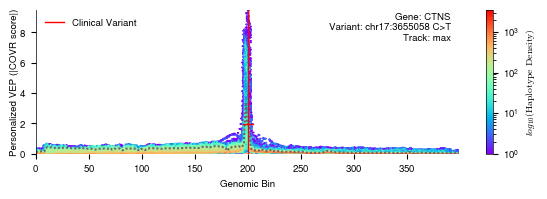

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [329]:
# trks_covr is organized as site_name -> [sample, (top) track, position]
gene="CTNS"
middle_n = 400
covr_interhaplotype_variation_out = fz.plot_covr_interhaplotype_variation(
    trks_covr = vp.get_middle_n(trks_covr_max, n=middle_n), 
    # top_tracks=top_tracks, 
    i=range(3), 
    gridsize_x=1000, 
    site_name=None, 
    show_site_label=False,
    unified_site_line=True,
    ylabel_offset=0.05,
    title_prefix="",
    # signed=True,
    agg_fun="max",
    
   ref_intersection_cross=False,
    ref_intersection_cross_size=.05,
    show_ref_intersection=True,
    ref_intersection_length=2.5*(middle_n/100),
    ref_intersection_kwargs={"color": "red", "linestyle": "-", "linewidth": 1},
    # ref_intersection_length=(middle_n if middle_n is not None else 100)//4,
    ref_label_offset=-3,
    ref_line_kwargs={"color": "dimgrey", "lw": 1.5, 
                    "linestyle": (0, (1, 1)),
                    # "linestyle": (0, (3, 2))
    },

    variant_line_kwargs={"color": "red", "linestyle": "-", "linewidth": 1},

    show_mean_line=False,
    mean_line_kwargs={"color": "darkgoldenrod", "lw": 1, "linestyle": ":"},



    exclude_all_zero=False,
    gene=gene, 
    sharex=True, sharey=False, 
    figsize=(6, 2),
    title_inside=True,
    title_position="top_right"
)

fig = covr_interhaplotype_variation_out["fig"]
filename = f"manuscript/fig/{gene}_max_interhaplotype_variation_{site_name}"
if middle_n is not None:
    filename += f"_middle{middle_n}"
filename += ".pdf"

fig = utils.rasterize_figure(fig)

fig.savefig(filename, bbox_inches="tight")

### Multi-track

<string>:304: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


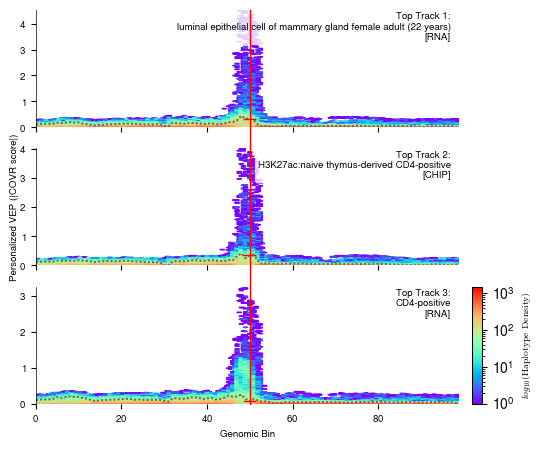

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


In [321]:
# trks_covr is organized as site_name -> [sample, (top) track, position]
gene="CTNS"
middle_n = 100
covr_interhaplotype_variation_out = fz.plot_covr_interhaplotype_variation(
    trks_covr = vp.get_middle_n(trks_covr, n=middle_n), 
    top_tracks=top_tracks.sort_values(by=f"{site}_mean", ascending=False), 
    # top_tracks=top_tracks.sort_values(by="max_covr", ascending=False), 
    i=range(3), 
    gridsize_x=None, 
    site_name=None, 
    show_site_label=False,
    unified_site_line=True,
        ylabel_offset=0.05,
    # signed=True,
    # agg_fun="max",
    
    title_position=None,
    ref_intersection_cross=False,
    ref_intersection_cross_size=.05,
    show_ref_intersection=True,
    ref_intersection_length=2.5,
    ref_intersection_kwargs={"color": "red", "linestyle": "-", "linewidth": 1},
    # ref_intersection_length=(middle_n if middle_n is not None else 100)//4,
    ref_label_offset=-3,
    ref_line_kwargs={"color": "dimgrey", "lw": 1.5, 
                    "linestyle": (0, (1, 1)),
                    # "linestyle": (0, (3, 2))
    },

    variant_line_kwargs={"color": "red", "linestyle": "-", "linewidth": 1},

    show_mean_line=False,
    mean_line_kwargs={"color": "darkgoldenrod", "lw": 1, "linestyle": ":"},


    exclude_all_zero=False,
    gene=gene, 
    sharex=True, sharey=False, 
    figsize=(4.9, 1.5*3),
    title_inside=True,
)

fig = covr_interhaplotype_variation_out["fig"]
filename = f"manuscript/fig/{gene}_top_tracks_interhaplotype_variation_{site_name}"
if middle_n is not None:
    filename += f"_middle{middle_n}"
filename += ".pdf"

fig = utils.rasterize_figure(fig)

fig.savefig(filename, bbox_inches="tight")

In [ ]:
# Example usage: minimal, no labels/legends; 3 concentric circles, with chord diagram
gene = "CTNS"
middle_n = 1000
covr_concentric_hexbin = fz.plot_covr_concentric_hexbin(
    trks_covr=vp.get_middle_n(trks_covr, n=middle_n), 
    i=range(10),
    # gridsize_ang=2000,
    # gridsize_rad=500,
    site_name=None, 
    exclude_all_zero=False,
    # gap_ratio=-1,
    signed=False, 
)


In [17]:
fig = covr_concentric_hexbin["fig"]
fig.savefig("manuscript/fig/CTNS_echo.pdf",
            dpi=500)


### COVR: top tracks per sample

Get the track which contains the max COVR value for each sample.  
Then print the name and ontology terms for each of those tracks ranked by how frequently they are the top track.

In [215]:
# Subset to RNA tracks
trks_idx = targets.index[targets["description"].str.startswith("RNA:")].tolist()
# trks_idx = None

max_trk_counts = []
for site_name in trks_covr.keys():
    df_tmp = pd.DataFrame([x.numpy() for x in torch.unique(trks_covr[site_name][:,trks_idx,:].max(dim=2)[0].argmax(dim=1), return_counts=True)], 
                                index=["track_idx", "count"]
                                ).T.sort_values(by="count", ascending=False)
    df_tmp["site_name"] = site_name
    max_trk_counts.append(df_tmp)

max_trk_counts = pd.concat(max_trk_counts, axis=0)

# Get the top ontology labels for the top tracks
for col in ["name"]+[x for x in targets.columns if x.endswith("_LABEL")]:
    print(col)
    print(targets.iloc[max_trk_counts['track_idx'].values][col].dropna().tolist()[:20])
    print("\n")

name
['cerebral meninges', 'Clontech Human Universal Reference Total RNA', 'leiomyoma cell line:10964C', 'breast carcinoma cell line:MDA-MB-453', 'testis', 'adult T-cell leukemia cell line:ATN-1', 'Clontech Human Universal Reference Total RNA']


EFO_LABEL
['total RNA', 'breast carcinoma', 'T-cell acute lymphoblastic leukemia', 'total RNA']


UBERON_LABEL
['meningeal cluster', 'breast', 'testis']


CL_LABEL
['adipocyte of breast', 'T cell']


CLO_LABEL
['GM10964 cell', locstr('mouse leukemia cell line cell', 'en')]


MONDO_LABEL
['cerebral meningioma', 'pancolitis', 'leiomyoma', 'breast carcinoma', 'neoplasm of testis', 'T-cell acute lymphoblastic leukemia', 'pancolitis']


ONT_LABEL
['meningeal cluster', 'total RNA', 'leiomyoma', 'breast carcinoma', 'testis', 'T-cell acute lymphoblastic leukemia', 'total RNA']




In [ ]:
top_trks_idx = np.argsort(trks_covr[site_name].var(dim=0).mean(dim=1))
targets.iloc[top_trks_idx[:20]]

,idx,identifier,file,clip,clip_soft,scale,sum_stat,strand_pair,description,species,source,assay,name,EFO_ID,EFO_LABEL,EFO_SCORE,UBERON_ID,UBERON_LABEL,UBERON_SCORE,CL_ID,CL_LABEL,CL_SCORE,CLO_ID,CLO_LABEL,CLO_SCORE,Source Term,MONDO_ID,MONDO_LABEL,MONDO_SCORE,ONT_TOP,ONT_LABEL,ONT_SCORE,chr19:11131368-11131369_G_A,chr19:11132656-11132657_C_A
5721,5721,ENCFF254GWA,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,5721,CHIP:H3K4me3:transverse colon female adult (53...,human,encode,CHIP,H3K4me3:transverse colon female adult (53 years),NaN,NaN,NaN,UBERON:0001157,transverse colon,0.801,NaN,NaN,NaN,NaN,NaN,NaN,H3K4me3:transverse colon female adult (53 years),MONDO:0002361,transverse colon cancer,0.753,UBERON,transverse colon,0.801,0.936620,1.926060
3643,3643,ENCFF363FAB,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,3643,CHIP:H3K4me1:tibial artery female adult (53 ye...,human,encode,CHIP,H3K4me1:tibial artery female adult (53 years),NaN,NaN,NaN,UBERON:0007610,tibial artery,0.772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UBERON,tibial artery,0.772,5.233031,2.901458
3216,3216,ENCFF601GYH,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,3216,CHIP:H3K4me1:T-helper 17 cell treated with pho...,human,encode,CHIP,H3K4me1:T-helper 17 cell treated with phorbol ...,NaN,NaN,NaN,NaN,NaN,NaN,CL:0000912,helper T cell,0.374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CL,helper T cell,0.374,4.657895,2.318313
4861,4861,ENCFF922CAD,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,4861,CHIP:H3K27me3:transverse colon male adult (37 ...,human,encode,CHIP,H3K27me3:transverse colon male adult (37 years),NaN,NaN,NaN,UBERON:0001157,transverse colon,0.783,NaN,NaN,NaN,NaN,NaN,NaN,H3K27me3:transverse colon male adult (37 years),MONDO:0002361,transverse colon cancer,0.736,UBERON,transverse colon,0.783,1.557896,2.562834
3601,3601,ENCFF013BCN,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,3601,CHIP:ZFX:HEK293T,human,encode,CHIP,ZFX:HEK293T,EFO:0001082,HEK293T,0.697,NaN,NaN,NaN,NaN,NaN,NaN,CLO:0037372,HEK293T cell,0.695,NaN,NaN,NaN,NaN,EFO,HEK293T,0.697,2.408999,2.945123
2156,2156,kai76,/home/drk/tillage/datasets/human/atac/catlas/k...,384,96,0.01,sum,2156,ATAC:Fetal Erythroblast 1,human,catlas,ATAC,Fetal Erythroblast 1,EFO:1000937,fetal erythroblastosis,0.852,NaN,NaN,NaN,CL:0000765,erythroblast,0.890,CLO:0000151,immortal erythroblast cell line cell,0.778,Fetal Erythroblast 1,MONDO:0006760,fetal erythroblastosis,0.857,CL,erythroblast,0.890,0.713263,2.177029
2006,2006,kai140,/home/drk/tillage/datasets/human/atac/catlas/k...,384,96,0.01,sum,2006,ATAC:Fetal Skeletal Myocyte 1,human,catlas,ATAC,Fetal Skeletal Myocyte 1,EFO:0020898,skeletal age,0.607,UBERON:0004765,skeletal element,0.558,CL:0000515,skeletal muscle myoblast,0.598,NaN,NaN,NaN,Fetal Skeletal Myocyte 1,MONDO:0021054,bone sarcoma,0.558,EFO,skeletal age,0.607,1.609268,2.304523
2157,2157,kai77,/home/drk/tillage/datasets/human/atac/catlas/k...,384,96,0.01,sum,2157,ATAC:Fetal Erythroblast 2,human,catlas,ATAC,Fetal Erythroblast 2,EFO:1000937,fetal erythroblastosis,0.844,NaN,NaN,NaN,CL:0000765,erythroblast,0.882,CLO:0000151,immortal erythroblast cell line cell,0.771,Fetal Erythroblast 2,MONDO:0006760,fetal erythroblastosis,0.849,CL,erythroblast,0.882,1.066909,2.301498
2949,2949,ENCFF731PKC,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,2949,CHIP:H3K4me3:mesenchymal stem cell originated ...,human,encode,CHIP,H3K4me3:mesenchymal stem cell originated from ...,EFO:0005023,adipose tissue derived mesenchymal stem cell,0.810,NaN,NaN,NaN,CL:0002570,mesenchymal stem cell of adipose tissue,0.863,CLO:0037305,mesenchymal stem cell line cell,0.641,NaN,NaN,NaN,NaN,CL,mesenchymal stem cell of adipose tissue,0.863,10.382904,2.678184
4131,4131,ENCFF608OTO,/home/drk/tillage/datasets/human/chip/encode/E...,128,32,2.00,mean,4131,CHIP:H3K27ac:adrenal gland male adult (34 years),human,encode,CHIP,H3K27ac:adrenal gland male adult (34 years),EF

### COVR: compute mean COVR for each site

In [ ]:
trks_covr_mean = {site_name: v.mean(dim=0) for site_name,v in trks_covr.items()}
{site_name: v.shape for site_name,v in trks_covr_mean.items()}

{'chr19:11131368-11131369_G_A': torch.Size([7611, 62]),
 'chr19:11132656-11132657_C_A': torch.Size([7611, 62])}

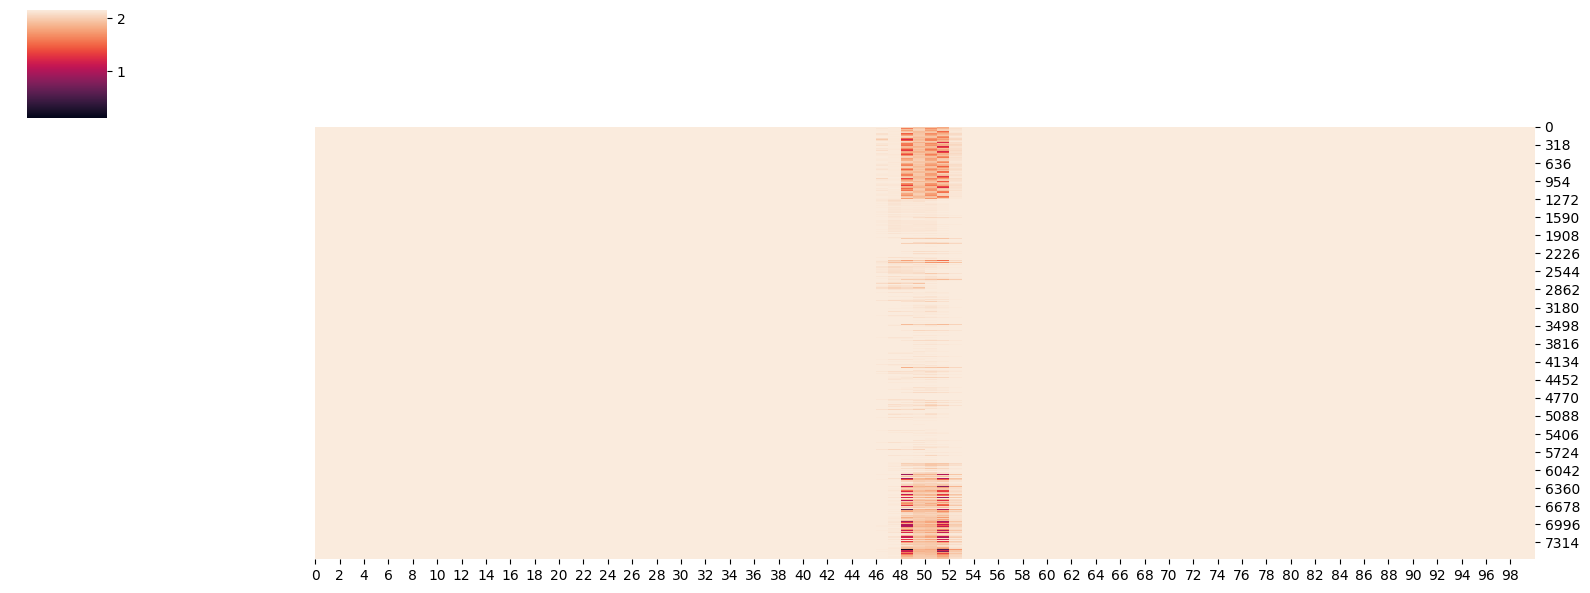

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



bin_size = 1  # Set your desired bin size here
# dat_binned = bin_along_axis(
#     # data = trks_covr_mean[site_name].cpu().numpy(),
#     data = entropy(trks_covr[site_name]).cpu().numpy(),
#                             bin_size = bin_size, 
#                             axis=1)
# dat_binned = np.log2(np.abs(dat_binned))

dat_binned = entropy(vp.get_middle_n(trks_covr[site_name], 100), dim=0)
dat_binned = np.log2(dat_binned)


# Create the clustermap
g = sns.clustermap(dat_binned.cpu().numpy(), 
                   col_cluster=False,
                   row_cluster=False,
                   figsize=(16, 6))

# Adjust x-axis tick labels to reflect original coordinates
ax = g.ax_heatmap
xticks = ax.get_xticks()
# Only keep ticks that are within the data range
xticks = [int(tick) for tick in xticks if 0 <= tick < dat_binned.shape[1]]
ax.set_xticks(xticks)
ax.set_xticklabels([str(tick * bin_size) for tick in xticks])

plt.show()

In [134]:
max_trk_counts

,track_idx,count,site_name
2,974,65,chr19:11131368-11131369_G_A
0,0,20,chr19:11131368-11131369_G_A
1,486,1,chr19:11131368-11131369_G_A
1,108,68,chr19:11132656-11132657_C_A
3,1013,11,chr19:11132656-11132657_C_A
2,112,4,chr19:11132656-11132657_C_A
0,0,3,chr19:11132656-11132657_C_A


Plot the difference between the mean of the mutated and wild type tracks for each site. 












In [217]:
def get_values(x):
    return x.abs().mean(dim=0).max(dim=0)[0].cpu().numpy()

trk_idx = 0 
plot_data = []
for site_name in trks_mut.keys(): 
    plot_data.append({
        "site_name": site_name,
        "trk_idx": trk_idx, 
        "position_idx": np.arange(get_values(trks_mut[site_name]).shape[0]),
        "wt_value": get_values(trks_wt[site_name]),
        "mut_value": get_values(trks_mut[site_name]),
        
    }) 

plot_data = pd.DataFrame(plot_data).explode(["position_idx", "mut_value", "wt_value"])
plot_data["diff"] = plot_data["mut_value"] - plot_data["wt_value"]
plot_data
 

,site_name,trk_idx,position_idx,wt_value,mut_value,diff
0,chr19:11131368-11131369_G_A,0,0,33.069599,33.0658,-0.003799
0,chr19:11131368-11131369_G_A,0,1,35.66692,35.66296,-0.00396
0,chr19:11131368-11131369_G_A,0,2,38.01532,38.010998,-0.004322
0,chr19:11131368-11131369_G_A,0,3,39.545597,39.540699,-0.004898
0,chr19:11131368-11131369_G_A,0,4,39.713451,39.709362,-0.004089
...,...,...,...,...,...,...
1,chr19:11132656-11132657_C_A,0,6139,25.351643,25.352486,0.000843
1,chr19:11132656-11132657_C_A,0,6140,23.430916,23.431244,0.000328
1,chr19:11132656-11132657_C_A,0,6141,19.30028,19.299646,-0.000633
1,chr19:11132656-11132657_C_A,0,6142,18.445509,18.444897,-0.000612


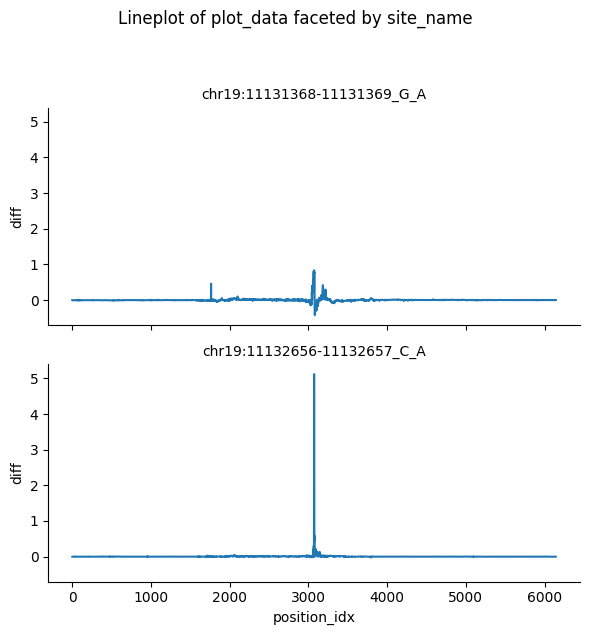

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt 

# Facet by site_name using seaborn's FacetGrid
g = sns.FacetGrid(plot_data, col="site_name", col_wrap=1, height=3, aspect=2, sharey=True, sharex=True)
g.map_dataframe(sns.lineplot, x="position_idx", y="diff")

g.set_titles(col_template="{col_name}")
g.fig.suptitle("Lineplot of plot_data faceted by site_name", y=1.05)
plt.tight_layout()
plt.show()



Plot the regions where there is simply the most entropy in the WT tracks.

In [220]:
def get_values(x):
    return entropy(x, dim=0).mean(dim=0).cpu().numpy()

trk_idx = 0 
plot_data = []
for site_name in trks_mut.keys(): 
    plot_data.append({
        "site_name": site_name,
        "trk_idx": trk_idx, 
        "position_idx": np.arange(get_values(trks_mut[site_name]).shape[0]),
        "wt_value": get_values(trks_wt[site_name]),
        "mut_value": get_values(trks_mut[site_name]),
        
    }) 

plot_data = pd.DataFrame(plot_data).explode(["position_idx", "mut_value", "wt_value"])
plot_data["diff"] = plot_data["mut_value"] - plot_data["wt_value"]
plot_data
 

,site_name,trk_idx,position_idx,wt_value,mut_value,diff
0,chr19:11131368-11131369_G_A,0,0,4.448411,4.448412,0.000001
0,chr19:11131368-11131369_G_A,0,1,4.448768,4.448766,-0.000002
0,chr19:11131368-11131369_G_A,0,2,4.448854,4.448851,-0.000003
0,chr19:11131368-11131369_G_A,0,3,4.448975,4.448974,-0.000001
0,chr19:11131368-11131369_G_A,0,4,4.448888,4.448888,0.0
...,...,...,...,...,...,...
1,chr19:11132656-11132657_C_A,0,6139,4.448537,4.448538,0.000001
1,chr19:11132656-11132657_C_A,0,6140,4.44873,4.448732,0.000001
1,chr19:11132656-11132657_C_A,0,6141,4.449227,4.449227,0.0
1,chr19:11132656-11132657_C_A,0,6142,4.44946,4.449461,0.000002


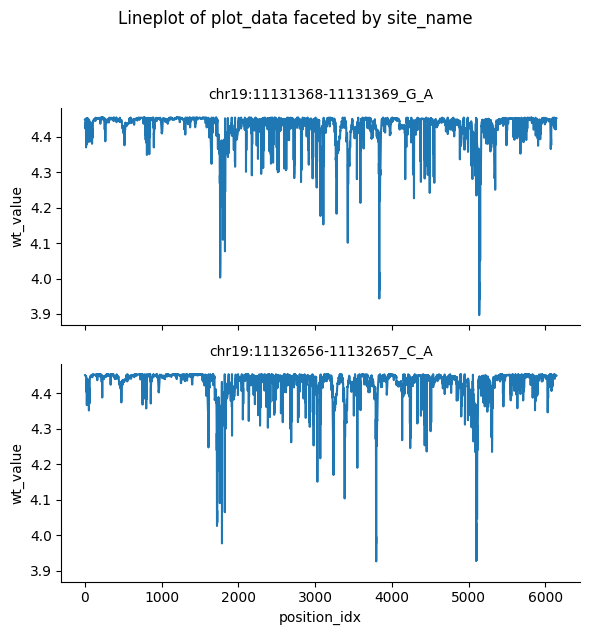

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt 

# Facet by site_name using seaborn's FacetGrid
plot_data
g = sns.FacetGrid(plot_data, col="site_name", col_wrap=1, height=3, aspect=2, sharey=True, sharex=True)
g.map_dataframe(sns.lineplot, x="position_idx", y="wt_value")

g.set_titles(col_template="{col_name}")
g.fig.suptitle("Lineplot of plot_data faceted by site_name", y=1.05)
plt.tight_layout()
plt.show()

